[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mayo-Radiology-Informatics-Lab/MIDeL/blob/main/chapters/2-3.ipynb)

*Author: Sahika Betul Yayli, MD*

## **Regression with Medical Data: Parkinson’s Telemonitoring**

In this notebook, we introduce **regression** as a fundamental machine learning task, with a focus on its role in clinical and biomedical applications.

Regression aims to learn a mapping from input features to a **continuous numerical output**. What defines regression is **the type of output it produces**, not the number of input variables used by the model.

This notebook is designed as an educational example to illustrate how regression models learn quantitative relationships and generate meaningful, consistent numerical predictions using a real medical dataset.

---

## What You Will Learn

- What a **regression task** is in clinical terms  
- How to build a **baseline model** and simple machine learning models  
- How to evaluate regression using **MAE, RMSE, and R²**  
- How to perform a basic **error analysis** using residuals  

**Audience:** Healthcare professionals new to machine learning  
**Assumptions:** Basic Python familiarity (variables, functions)

---

## What Is Regression?

**Regression** refers to the task of predicting a **continuous value** based on available input information.

Unlike classification, which assigns inputs to discrete categories, regression models estimate **how much** or **to what degree** a clinical or biological phenomenon is present.

> **In short:**  
> Regression answers the question *“What is the expected value?”*


## Why Regression Matters in Medical AI

Many clinically relevant outcomes exist on a continuous spectrum rather than as binary states.

Regression models enable:
- Quantitative assessment of disease severity
- Monitoring of changes over time
- Support for downstream clinical decision-making

Small numerical differences may carry significant clinical meaning, particularly near diagnostic or therapeutic thresholds.


## Regression vs Classification

Regression and classification address different types of clinical questions.

| Task Type | Core Question | Output |
|---------|--------------|--------|
| **Regression** | “What is the value?” | Continuous number |
| **Classification** | “Which group does this belong to?” | Discrete label |

While classification can be useful for screening or triage, regression preserves the full quantitative information required for disease grading and progression monitoring.

---

## The Task in This Notebook

This notebook uses the **Parkinson’s Telemonitoring dataset**, which was collected to study the relationship between **voice characteristics** and **motor symptom severity** in patients with Parkinson’s disease.

Parkinson’s disease is a progressive neurodegenerative disorder characterized by motor symptoms such as bradykinesia, rigidity, tremor, and postural instability. Disease severity is commonly assessed using standardized rating scales rather than binary diagnoses, making it a natural application area for regression models.



#### Clinical Target: motor_UPDRS

The target variable in this notebook is **motor_UPDRS**, a continuous clinical score derived from the **Unified Parkinson’s Disease Rating Scale (UPDRS)**.

- Higher values indicate greater motor impairment  
- The score reflects disease severity on a continuous spectrum  

Predicting motor_UPDRS is therefore a clinically meaningful regression task, where even modest numerical differences may correspond to meaningful changes in patient function.



#### Input Features: Clinical Overview

Each row in the dataset corresponds to a single patient visit and includes demographic information, timing information, and multiple voice-derived acoustic features.

**Demographic and Temporal Variables**
- **subject#**: Patient identifier (used for grouping only, not prediction)
- **age**: Patient age
- **sex**: Biological sex
- **test_time**: Time since baseline assessment

**Voice-Derived Acoustic Features**

Parkinson’s disease affects fine motor control, including speech production. As a result, voice signals provide sensitive markers of motor dysfunction.

The acoustic features capture:
- **Frequency instability** in speech (jitter-related measures)
- **Amplitude variability** (shimmer-related measures)
- **Noise characteristics** of the voice signal (NHR, HNR)
- **Nonlinear dynamical properties** reflecting neurological impairment (RPDE, DFA, PPE)

Together, these features provide complementary information about motor control and disease severity.


## Educational Perspective

From an educational standpoint, this dataset allows us to demonstrate how regression models:
- Integrate multiple heterogeneous input features
- Learn quantitative relationships in clinical data
- Produce interpretable numerical predictions
- Are evaluated using clinically relevant error metrics

Although the models used in this notebook are simplified, the underlying concepts generalize directly to more advanced regression models used in real-world medical AI applications.

---

## 1) Setup and dependencies

This notebook uses common Python libraries:
- `pandas` for tables
- `numpy` for math
- `scikit-learn` for machine learning
- `matplotlib` for plots


In [20]:
# If you are running this in a clean environment (e.g., Colab),
# you can uncomment the next line.

# !pip -q install pandas numpy scikit-learn matplotlib


## 2) Import libraries

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 3) Download and load the dataset

**Dataset:** Parkinson’s Telemonitoring (UCI)

- Each row is a **voice recording** from a patient visit.
- Columns are **acoustic features**.
- Targets include:
  - `motor_UPDRS` (motor symptom severity)
  - `total_UPDRS` (overall severity)

We will predict **`motor_UPDRS`** as a regression target.

> If the direct download is blocked in your environment, this cell also tries a fallback via OpenML.


In [ ]:
# pip install ucimlrepo

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
parkinsons_telemonitoring = fetch_ucirepo(id=189) 
  
# data (as pandas dataframes) 
X = parkinsons_telemonitoring.data.features 
y = parkinsons_telemonitoring.data.targets 
  
# metadata 
print(parkinsons_telemonitoring.metadata) 
  
# variable information 
print(parkinsons_telemonitoring.variables)

'# pip install ucimlrepo\n\nfrom ucimlrepo import fetch_ucirepo \n  \n# fetch dataset \nparkinsons_telemonitoring = fetch_ucirepo(id=189) \n  \n# data (as pandas dataframes) \nX = parkinsons_telemonitoring.data.features \ny = parkinsons_telemonitoring.data.targets \n  \n# metadata \nprint(parkinsons_telemonitoring.metadata) \n  \n# variable information \nprint(parkinsons_telemonitoring.variables) '

In [ ]:
import urllib.request

DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons_updrs.data"
LOCAL_PATH = "parkinsons_updrs.data"

def download_if_needed(url: str, path: str) -> None:
    if os.path.exists(path):
        return
    print(f"Downloading dataset to: {path}")
    urllib.request.urlretrieve(url, path)

df = None

try:
    download_if_needed(DATA_URL, LOCAL_PATH)
    df = pd.read_csv(LOCAL_PATH)
    print("Loaded from UCI:", df.shape)
except Exception as e:
    print("UCI download failed. Trying OpenML fallback...")
    print("Error:", e)
    from sklearn.datasets import fetch_openml
    # The OpenML name can vary; this tries a common one.
    df = fetch_openml(name="parkinsons_telemonitoring", as_frame=True).frame
    print("Loaded from OpenML:", df.shape)

df.head()

'import urllib.request\n\nDATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons_updrs.data"\nLOCAL_PATH = "parkinsons_updrs.data"\n\ndef download_if_needed(url: str, path: str) -> None:\n    if os.path.exists(path):\n        return\n    print(f"Downloading dataset to: {path}")\n    urllib.request.urlretrieve(url, path)\n\ndf = None\n\ntry:\n    download_if_needed(DATA_URL, LOCAL_PATH)\n    df = pd.read_csv(LOCAL_PATH)\n    print("Loaded from UCI:", df.shape)\nexcept Exception as e:\n    print("UCI download failed. Trying OpenML fallback...")\n    print("Error:", e)\n    from sklearn.datasets import fetch_openml\n    # The OpenML name can vary; this tries a common one.\n    df = fetch_openml(name="parkinsons_telemonitoring", as_frame=True).frame\n    print("Loaded from OpenML:", df.shape)\n\ndf.head()\n'

## 4) Understand the problem (clinical framing)

Quick dataset summary:

In [43]:
print(df.columns.tolist())
df.describe(include="all").T.head(15)

['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


,count,mean,std,min,25%,50%,75%,max
subject#,5875.0,21.494128,12.372279,1.000000,10.000000,22.000000,33.000000,42.000000
age,5875.0,64.804936,8.821524,36.000000,58.000000,65.000000,72.000000,85.000000
sex,5875.0,0.317787,0.465656,0.000000,0.000000,0.000000,1.000000,1.000000
test_time,5875.0,92.863722,53.445602,-4.262500,46.847500,91.523000,138.445000,215.490000
motor_UPDRS,5875.0,21.296229,8.129282,5.037700,15.000000,20.871000,27.596500,39.511000
total_UPDRS,5875.0,29.018942,10.700283,7.000000,21.371000,27.576000,36.399000,54.992000
Jitter(%),5875.0,0.006154,0.005624,0.000830,0.003580,0.004900,0.006800,0.099990
Jitter(Abs),5875.0,0.000044,0.000036,0.000002,0.000022,0.000035,0.000053,0.000446
Jitter:RAP,5875.0,0.002987,0.003124,0.000330,0.001580,0.002250,0.003290,0.057540
Jitter:PPQ5,5875.0,0.003277,0.003732,0.000430,0.001820,0.002490,0.003460,0.069560


## 5) Define features (X) and target (y)

At this stage, we explicitly define the **input features (X)** and the **prediction target (y)** for the regression task.

We make the following design choices:

- **Dropping identifiers to prevent data leakage**  
  Columns such as `subject#` and `test_time` are not biological predictors of disease severity.  
  Including them may allow the model to memorize patient-specific patterns or visit order rather than learn generalizable clinical relationships.

- **Using remaining numeric variables as features**  
  The remaining columns represent demographic information and voice-derived acoustic measurements that are plausibly related to motor symptom severity.

- **Defining `motor_UPDRS` as the target**  
  The `motor_UPDRS` score is a continuous clinical measure of motor impairment and represents the outcome we want the model to predict.

These steps ensure that the model is trained to learn **clinically meaningful and generalizable relationships**, rather than exploiting identifiers or temporal artifacts present in the dataset.

In [25]:
TARGET = "motor_UPDRS"

# Columns that are not useful for prediction or can leak information
DROP_COLS = ["subject#", "test_time"]  # identifiers / time index

# Basic sanity checks
assert TARGET in df.columns, f"Target column '{TARGET}' not found."
for c in DROP_COLS:
    if c in df.columns:
        pass

y = df[TARGET].astype(float)
X = df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns])

# Keep only numeric features (this dataset is numeric, but we keep it safe)
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X = X[numeric_cols]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (5875, 19)
y shape: (5875,)


## 6) Train / test split

We split data into:
- **train**: used to fit the model
- **test**: used only at the end to estimate real-world performance

> Note: This dataset has repeated measures per subject.  
> For a truly patient-independent evaluation, you would do a **group split** by patient ID.  
> We keep it simple here to teach the core idea of regression.


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (4700, 19) (4700,)
Test : (1175, 19) (1175,)


## 7) Baseline model (very important!)

Before using any “smart” machine learning model, we first build a **baseline**.

A common baseline for regression is to:
- always predict the **mean** of the training target

This baseline represents a model that ignores all input features and assumes every patient is “average.”

A useful regression model should **meaningfully outperform this baseline**.  
If it cannot, this suggests that the model is not effectively leveraging the available information in the data.


In [27]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

pred_base = baseline.predict(X_test)

mae_base = mean_absolute_error(y_test, pred_base)
mse_base = mean_squared_error(y_test, pred_base)
rmse_base = np.sqrt(mse_base)
r2_base = r2_score(y_test, pred_base)

print(f"Baseline MAE : {mae_base:.3f}")
print(f"Baseline RMSE: {rmse_base:.3f}")
print(f"Baseline R²  : {r2_base:.3f}")


Baseline MAE : 6.878
Baseline RMSE: 7.991
Baseline R²  : -0.001


## 8) Build Simple Regression Models

After establishing a baseline, we now train regression models that can **use input features** to make patient-specific predictions.

We introduce two commonly used regression models with different characteristics.

### a) Ridge Regression (Linear Model)

Ridge Regression is a **linear regression model**, meaning it assumes a weighted sum of the input features is used to predict the outcome.

It includes **regularization**, a mechanism that:
- Penalizes overly large coefficients
- Helps prevent overfitting
- Improves stability when features are correlated

Linear models are often used as a first step in medical machine learning because they are relatively **interpretable** and easy to analyze.

### b) Random Forest Regressor (Non-Linear Model)

Random Forest is a **non-linear regression model** that combines predictions from many decision trees.

Unlike linear models, it can:
- Capture complex interactions between features
- Model non-linear relationships without explicit assumptions

Random Forest models are commonly used when relationships between clinical variables and outcomes are not well described by a simple linear pattern.

### Why Do We Scale Features?

Some regression models, particularly **linear models**, are sensitive to the scale of numeric features.

Feature scaling ensures that:
- All input variables contribute comparably to the model
- Model training is more stable and efficient

We use `StandardScaler` within a pipeline so that:
- Scaling is applied consistently during training and testing
- The preprocessing steps remain tightly coupled with the model

In [28]:
# Preprocessing: impute missing values (if any) + scale
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols)
    ],
    remainder="drop"
)

ridge_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0, random_state=42))
])

rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

ridge_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

### Evaluate both models on the test set


#### MAE (Mean Absolute Error)
- Average absolute error: “on average, how far off are we?”
- Same units as the target (here: UPDRS points)
- Often easy to interpret clinically

#### RMSE (Root Mean Squared Error)
- Similar units as the target
- Penalizes large errors more than MAE
- Useful when big errors are especially harmful

#### R² (Coefficient of Determination)
- How much variance the model explains compared to predicting the mean
- 1.0 is perfect, 0.0 is baseline, negative means worse than baseline

> In healthcare, it can also be helpful to report:
> - **Median Absolute Error** (robust to outliers)
> - **Calibration across ranges** (does the model fail for severe cases?)


In [30]:
def eval_regression(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # <- squared=False yerine
    r2 = r2_score(y_true, y_pred)
    return pd.DataFrame([{
        "Model": name,
        "MAE (↓)": mae,
        "RMSE (↓)": rmse,
        "R² (↑)": r2
    }])

results = pd.concat([
    eval_regression("Baseline (Mean)", y_test, pred_base),
    eval_regression("Ridge Regression", y_test, pred_ridge),
    eval_regression("Random Forest", y_test, pred_rf),
], ignore_index=True)

results

,Model,MAE (↓),RMSE (↓),R² (↑)
0,Baseline (Mean),6.877785,7.991393,-0.000519
1,Ridge Regression,1.880425,2.447443,0.906156
2,Random Forest,0.288811,0.498613,0.996105


## 9) Visualize predictions (parity plot)

A helpful plot for regression is a **parity plot**:
- x-axis: true value
- y-axis: predicted value

Perfect predictions would lie on the diagonal line.

Baseline models are primarily used as numerical reference points. 
Visual diagnostics such as parity and residual plots are most informative for models that actively use input features to make predictions.

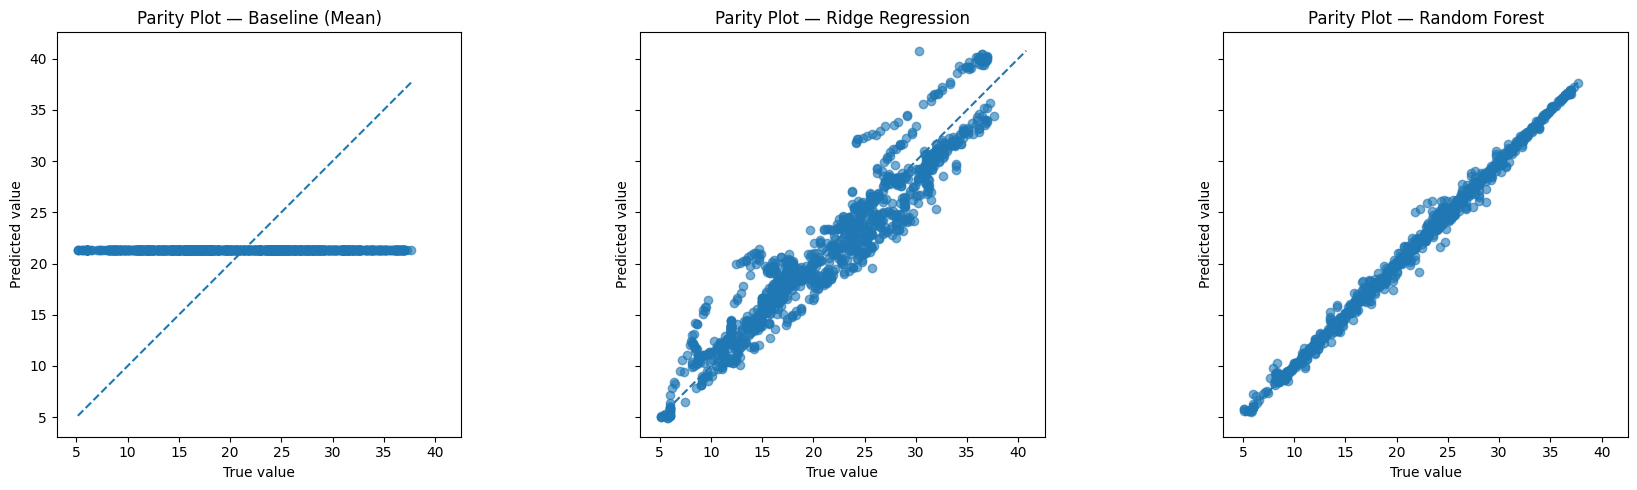

In [45]:
import matplotlib.pyplot as plt

def parity_plot(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.6)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], linestyle="--")
    ax.set_xlabel("True value")
    ax.set_ylabel("Predicted value")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

parity_plot(axes[0], y_test, pred_base, "Parity Plot — Baseline (Mean)")
parity_plot(axes[1], y_test, pred_ridge, "Parity Plot — Ridge Regression")
parity_plot(axes[2], y_test, pred_rf, "Parity Plot — Random Forest")

plt.tight_layout()
plt.show()

## 10) Error analysis (residuals)

**Residual = (true - predicted)**

Residual plots can reveal:
- bias (systematic under/over prediction)
- larger errors in certain ranges (heteroscedasticity)


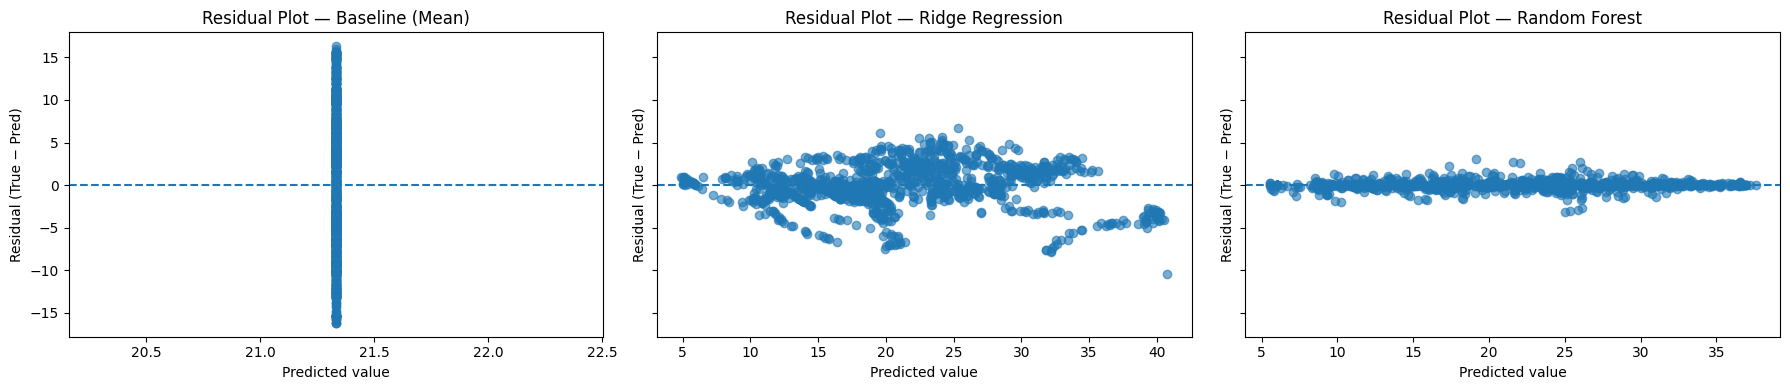

In [47]:
import matplotlib.pyplot as plt

def residual_plot(ax, y_true, y_pred, title):
    residuals = y_true - y_pred
    ax.scatter(y_pred, residuals, alpha=0.6)
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Predicted value")
    ax.set_ylabel("Residual (True − Pred)")
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

residual_plot(axes[0], y_test, pred_base, "Residual Plot — Baseline (Mean)")
residual_plot(axes[1], y_test, pred_ridge, "Residual Plot — Ridge Regression")
residual_plot(axes[2], y_test, pred_rf, "Residual Plot — Random Forest")

plt.tight_layout()
plt.show()


In [40]:
# Show the best model according to each metric
best_mae_model = results.sort_values("MAE (↓)").iloc[0]["Model"]
best_rmse_model = results.sort_values("RMSE (↓)").iloc[0]["Model"]
best_r2_model = results.sort_values("R² (↑)", ascending=False).iloc[0]["Model"]

print("Best by MAE :", best_mae_model)
print("Best by RMSE:", best_rmse_model)
print("Best by R²  :", best_r2_model)


Best by MAE : Random Forest
Best by RMSE: Random Forest
Best by R²  : Random Forest


## 11) Interpretability

In our small model comparison, **Random Forest** achieved the best performance across all three evaluation metrics (MAE, RMSE, and R²).  
For this reason, we focus our interpretability discussion on the Random Forest model.


### Feature Importance in Random Forest

Although Random Forest models are less directly interpretable than linear models, they can provide **feature importance scores**.

Feature importance reflects:
- How much each feature contributes to reducing prediction error
- How often and how effectively a feature is used across the ensemble of decision trees

These scores do **not** indicate causal relationships, but they help identify which inputs the model relies on most when making predictions.


### Why Interpretability Matters in Healthcare

Interpretability is critical in medical AI because:

- Clinicians want to understand *which types of information* influence predictions  
- Feature importance can help detect spurious correlations or technical artifacts  
- It supports trust, transparency, and clinical plausibility checks  

Even when a model performs well numerically, examining feature importance provides an essential sanity check before considering any clinical application.


In [41]:
# Ridge coefficients (in scaled space). We map them back to feature names.
ridge = ridge_model.named_steps["model"]
coef = ridge.coef_

coef_df = pd.DataFrame({
    "feature": numeric_cols,
    "coef": coef
}).sort_values("coef", ascending=False)

coef_df.head(10)


,feature,coef
2,total_UPDRS,7.758063
3,Jitter(%),1.074357
12,Shimmer:APQ11,0.831345
8,Shimmer,0.567995
18,PPE,0.456863
1,sex,0.414228
15,HNR,0.069898
13,Shimmer:DDA,0.023040
9,Shimmer(dB),0.018795
10,Shimmer:APQ3,0.002536


The Ridge Regression coefficients indicate how each feature contributes to the predicted `motor_UPDRS` score in a linear model. Larger positive coefficients correspond to features that are more strongly associated with higher motor symptom severity.

The dominance of **`total_UPDRS`** highlights a case of **information leakage**, as this score already contains motor-related components. This explains its large coefficient and underscores the importance of excluding such variables in a proper modeling setup.

Apart from this, several **voice-derived acoustic features** (e.g., jitter, shimmer, PPE) appear among the top coefficients, which is clinically plausible given that Parkinson’s disease affects fine motor control of speech.


## 12) Suggested exercises (optional)
1) Predict `total_UPDRS` instead of `motor_UPDRS`. What changes?
2) Add cross-validation (later chapters will cover this more).
3) Try a different model (e.g., Gradient Boosting).
4) Use a **patient-level split** (group split) using `subject#` to avoid leakage.


---

## Summary

**Key Takeaway:** Regression models are designed to predict continuous values by learning quantitative relationships between input features and outcomes.

This notebook uses a simplified setting to demonstrate core regression concepts, while remaining applicable to more complex, multi-variable clinical modeling scenarios.

You built:
- a **baseline** (mean predictor)
- a **linear model** (Ridge regression)
- a **non-linear model** (Random Forest)

And you evaluated them using:
- **MAE**
- **RMSE**
- **R²**

In later chapters, you can extend this with:
- loss functions, augmentation (for imaging), model selection, calibration, uncertainty, fairness, and external validation.